# Artificial Neural Networks and Deep Learning



---




# ⚙️ Install required dependencies

In this case, we utilized `keras-cv` a powerful library designed to support computer vision tasks such as data augmentation, classification, object detection, and segmentation. For this challenge, we primarily used this library to apply advanced augmentations to our training data, enhancing the model's ability to generalize effectively to new image sets.

In [1]:
%%capture

!pip uninstall -y tensorflow keras tensorflow-addons vit-keras keras-cv



In [2]:
!pip install keras-cv


!pip install pynrrd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 10.8 MB/s eta 0:00:00 0:00:01


In [3]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.3/615.3 MB 2.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 756.2 kB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 7.0 MB/s eta 0:00:000:00:01
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.10.0 requires tensorflow==2.17.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-text 2.17.0 requires tensorflow<2.18,>=2.17.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.18.0 which is incompatible.


In [4]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 2


In [5]:
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:


print("TensorFlow rileva GPU:", tf.config.list_physical_devices('GPU'))



TensorFlow rileva GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:
!nvidia-smi


Fri Feb  7 16:20:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
!echo $PATH | grep cuda


~/.local/bin:/opt/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin


In [9]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 7262189336280846169
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
    link {
      device_id: 1
      type: "StreamExecutor"
      strength: 1
    }
  }
}
incarnation: 16045511564183824899
physical_device_desc: "device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5"
xla_global_id: 416903419
, name: "/device:GPU:1"
device_type: "GPU"
memory_limit: 14619377664
locality {
  bus_id: 1
  links {
    link {
      type: "StreamExecutor"
      strength: 1
    }
  }
}
incarnation: 9046701457131912904
physical_device_desc: "device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5"
xla_global_id: 2144165316
]


In [10]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))


True
2
Tesla T4


# ⚙️ Import libraries

In [11]:

import tensorflow as tf
from tensorflow import keras as tfk
import keras
from keras import layers as tfkl

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)



TensorFlow version: 2.18.0
Keras version: 3.8.0


In [12]:
import os

import logging
import numpy as np

import cv2

# Plot libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)


# Reduce TensorFlow verbosity
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

RANDOM_SEED = 200723
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED);

# 🧙 Auxiliary functions

#### Helper functions to identify and remove all the outliers

In [13]:
def check_overlay(image, template, threshold=0.99):
  """
    Checks if a given template matches a portion of the input image within a specified threshold.

    This function uses the OpenCV method `cv2.matchTemplate` to slide the template image over
    the input image (as in 2D convolution) and compares the template and the image patch
    under the template to compute a similarity score. If the maximum similarity score exceeds
    the provided threshold, the function returns True, indicating a match.

  """

  image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
  result = cv2.matchTemplate(image_gray, template, cv2.TM_CCOEFF_NORMED)
  _, max_val, _, max_loc = cv2.minMaxLoc(result)

  return max_val >= threshold

---

#### Plot random images for each label

In [14]:
# Plot a random image for each label
def plot_images(rows, images, labels):
  """
  Plots n_samples images for each label in a grid.

  Each row represents a different sample, and each column represents a different label.
  """

  unique_labels = np.unique(labels)
  cols = len(unique_labels) * 2

  plt.figure(figsize=(15, 5))


  # Iterate through samples and labels
  for i in range(rows):
      for j, label in enumerate(unique_labels):
          # Find an image with the current label
          label_indices = np.where(labels == label)[0]
          random_index = np.random.choice(label_indices, size=1)[0]

          # Calculate the subplot index for original image
          subplot_index_original = i * cols + j * 2 + 1

          # Plot the original image
          plt.subplot(rows, cols, subplot_index_original)
          plt.imshow(images[random_index], cmap="gray")
          plt.axis('off')

          # Add title only to the first row
          if i == 0:
              plt.title(f"Label: {label}", pad=10, fontsize=12)

  plt.tight_layout()
  plt.show()

#### Plot the labels distribution highlighting the split in "Training" and "Validation + Test"

In [15]:
def plot_labels_distribution(y_train, y_val, y_test):
  # Combine the labels from all three sets into one list to plot their distributions
  sets = ['Training', 'Validation + Test']
  y_test_val = np.concatenate([y_test, y_val])

  labels_sets = [y_train, y_test_val]

  # Create a figure to plot
  plt.figure(figsize=(12, 6))

  # Plot the class distributions for each set
  for i, labels in enumerate(labels_sets):
    # Calculate class distribution
    unique, counts = np.unique(labels, return_counts=True)
    distribution = dict(zip(unique, counts))

    # Plot each distribution with a different color
    sns.barplot(x=list(distribution.keys()), y=list(distribution.values()), label=sets[i], alpha=0.7)

  # Customize plot
  plt.title('Class Distribution in Training, Validation, and Test Sets', fontsize=16)
  plt.xlabel('Class Labels', fontsize=12)
  plt.ylabel('Number of Samples', fontsize=12)
  plt.legend(title='Data Set', loc='upper right')
  plt.xticks(rotation=45)
  plt.tight_layout()

  # Show the plot
  plt.show()

In [16]:
def analyze_pixel_values(images):
    """
    Calculates and prints the mean, standard deviation, minimum, and maximum
    pixel values in a given set of images.

    Parameters:
        images (numpy.ndarray): Array of images to analyze.
    """
    mean_pixel_value = images.mean()
    std_pixel_value = images.std()
    min_pixel_value = images.min()
    max_pixel_value = images.max()

    print("Mean pixel value:", mean_pixel_value)
    print("Standard deviation of pixel values:", std_pixel_value)
    print("Minimum pixel value:", min_pixel_value)
    print("Maximum pixel value:", max_pixel_value)


In [17]:
def plot_pixel_intensity_distribution(images, bins=50, color="skyblue"):
    """
    Plots the distribution of pixel intensities for a set of images.

    Parameters:
        images (numpy.ndarray): Array of images to analyze.
        bins (int): Number of bins for the histogram. Default is 50.
        color (str): Color of the histogram bars. Default is "skyblue".

    Returns:
        None
    """
    plt.figure(figsize=(10, 5))
    plt.hist(images.ravel(), bins=bins, color=color)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.title("Pixel Intensity Distribution")
    plt.show()

In [18]:
def check_image_sizes(images_full_slice, images_nodule):
    """
    Checks if all images in the dataset have the same size for full_slice and nodule.

    Parameters:
        images_full_slice (numpy.ndarray): Array of full_slice images.
        images_nodule (numpy.ndarray): Array of nodule images.

    Returns:
        None
    """
    # Get the shape of the first image in each array
    full_slice_shape = images_full_slice[0].shape
    nodule_shape = images_nodule[0].shape

    # Check for inconsistent shapes in full_slice images
    inconsistent_full_slice = [img.shape for img in images_full_slice if img.shape != full_slice_shape]

    # Check for inconsistent shapes in nodule images
    inconsistent_nodule = [img.shape for img in images_nodule if img.shape != nodule_shape]

    # Print results
    if inconsistent_full_slice:
        print(f"Found inconsistent shapes in full_slice images: {inconsistent_full_slice}")
    else:
        print(f"All full_slice images have the same shape: {full_slice_shape}")

    if inconsistent_nodule:
        print(f"Found inconsistent shapes in nodule images: {inconsistent_nodule}")
    else:
        print(f"All nodule images have the same shape: {nodule_shape}")



---

# Model evaluation functions

In [19]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate_model(model, X_test, y_test):

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Predict probabilities for ROC AUC
    y_pred_prob = model.predict(X_test)

    # Get predicted labels (convert probabilities to class labels)
    y_pred = np.argmax(y_pred_prob, axis=1) if y_pred_prob.ndim > 1 and y_pred_prob.shape[1] > 1 else (y_pred_prob > 0.5).astype(int)

    # Convert one-hot encoded y_test to class labels, only if needed
    y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 and y_test.shape[1] > 1 else y_test


    # Calculate metrics
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    # Calculate ROC AUC for multi-class
    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc = None  # Handle cases where ROC AUC cannot be calculated

    # Print metrics
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"ROC AUC (weighted): {roc_auc:.4f}" if roc_auc is not None else "ROC AUC: Not Applicable")

    return test_accuracy, precision, recall, roc_auc

In [20]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import numpy as np

def evaluate_model_with_confidence(model, X_test, y_test):
    """
    Evaluates the model on the test set and computes accuracy, precision, recall, ROC AUC, 
    and estimated confidence for predictions.

    Parameters:
        model: Trained model to evaluate.
        X_test: Test set features.
        y_test: Test set labels (one-hot encoded).

    Returns:
        test_accuracy, precision, recall, roc_auc, average_confidence
    """
    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Predict probabilities for ROC AUC and confidence
    y_pred_prob = model.predict(X_test)

    # Get predicted labels (convert probabilities to class labels)
    y_pred = np.argmax(y_pred_prob, axis=1) if y_pred_prob.ndim > 1 and y_pred_prob.shape[1] > 1 else (y_pred_prob > 0.5).astype(int)

    # Convert one-hot encoded y_test to class labels, only if needed
    y_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 and y_test.shape[1] > 1 else y_test


    # Calculate metrics
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')

    # Calculate ROC AUC for multi-class
    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')
    except ValueError:
        roc_auc = None  # Handle cases where ROC AUC cannot be calculated

    # Calculate confidence
    confidences = np.max(y_pred_prob, axis=1)  # Maximum probability for each prediction
    average_confidence = np.mean(confidences)

    # Print metrics
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"ROC AUC (weighted): {roc_auc:.4f}" if roc_auc is not None else "ROC AUC: Not Applicable")
    print(f"Average Confidence: {average_confidence:.4f}")

    return test_accuracy, precision, recall, roc_auc, average_confidence


In [21]:
def plot_confusion_matrix(model, X_test, y_test, model_name=""):
    # Get model predictions
    y_test_prob = model.predict(X_test)

    # Convert predictions to class labels
    y_test_pred = np.argmax(y_test_prob, axis=1) if y_test_prob.ndim > 1 and y_test_prob.shape[1] > 1 else (y_test_prob > 0.5).astype(int)

    # Convert ground truth labels to class labels only if they are one-hot encoded
    y_test_true = np.argmax(y_test, axis=1) if y_test.ndim > 1 and y_test.shape[1] > 1 else y_test
    
    # Generate confusion matrix
    cm = confusion_matrix(y_test_true, y_test_pred)

    # Plot using seaborn heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

In [22]:
def plot_training_val_accuracy(history_transfer, history_fine, initial_epochs, model_name=""):
  acc = history_transfer.history['accuracy']
  val_acc = history_transfer.history['val_accuracy']

  loss = history_transfer.history['loss']
  val_loss = history_transfer.history['val_loss']

  acc += history_fine.history['accuracy']
  val_acc += history_fine.history['val_accuracy']

  loss += history_fine.history['loss']
  val_loss += history_fine.history['val_loss']

  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(acc, label='Training Accuracy')
  plt.plot(val_acc, label='Validation Accuracy')
  plt.ylim([0.8, 1])
  plt.plot([initial_epochs-1,initial_epochs-1],
            plt.ylim(), label='Start Fine Tuning')
  plt.legend(loc='lower right')
  plt.title(f'Training and Validation Accuracy for model {model_name}')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Training Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.ylim([0, 1.0])
  plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
  plt.legend(loc='upper right')
  plt.title(f'Training and Validation Loss for model {model_name}')
  plt.xlabel('epoch')
  plt.show()

# ⏳ Load the data

In [23]:
import nrrd
import os

def load_nrrd_files(data_path):
    images = {}
    for file in os.listdir(data_path):
        if file.endswith('.nrrd'):
            image, header = nrrd.read(os.path.join(data_path, file))
            images[file] = image
    return images

data_path = "/kaggle/input/train2/Train 2"
ct_images = load_nrrd_files(data_path)


In [24]:
# Print the structure of ct_images
print("Structure of ct_images:\n")
print(f"Type: {type(ct_images)}")
print(f"Number of images: {len(ct_images)}")
print("\nSample keys and corresponding values:\n")

# Display the first 5 keys and their corresponding shapes
for i, (file_name, image) in enumerate(ct_images.items()):
    print(f"Key (file name): {file_name}, Type: {type(image)}, Shape: {image.shape}")
    if i >= 4:  # Limit to first 5 entries
        break


Structure of ct_images:

Type: <class 'dict'>
Number of images: 4726

Sample keys and corresponding values:

Key (file name): pat2253_nodule.nrrd, Type: <class 'numpy.ndarray'>, Shape: (48, 48)
Key (file name): pat706_nodule.nrrd, Type: <class 'numpy.ndarray'>, Shape: (61, 63)
Key (file name): pat207_nodule.nrrd, Type: <class 'numpy.ndarray'>, Shape: (53, 51)
Key (file name): pat162_fullslice.nrrd, Type: <class 'numpy.ndarray'>, Shape: (512, 512)
Key (file name): pat1786_fullslice.nrrd, Type: <class 'numpy.ndarray'>, Shape: (512, 512)


In [25]:
import pandas as pd

labels = pd.read_excel("/kaggle/input/dataset-lung1/dataset_lung.xlsx")
print(labels.head())


            Full_slice            Nodule  TumorClass
0  pat1_fullslice.nrrd  pat1_nodule.nrrd           5
1  pat2_fullslice.nrrd  pat2_nodule.nrrd           5
2  pat3_fullslice.nrrd  pat3_nodule.nrrd           2
3  pat4_fullslice.nrrd  pat4_nodule.nrrd           5
4  pat5_fullslice.nrrd  pat5_nodule.nrrd           4


In [26]:
def match_images_with_labels(images, labels):
    """
    Matches images with corresponding labels and creates a new field for binary malignancy.

    Parameters:
        images: Dictionary of images with file names as keys.
        labels: DataFrame containing labels with file names and tumor class.

    Returns:
        A DataFrame containing matched images, labels, and binary malignancy.
    """
    data = []
    for index, row in labels.iterrows():
        full_slice_file = row['Full_slice']  # File name for full slice
        nodule_file = row['Nodule']          # File name for nodule
        malignancy = row['TumorClass']       # Malignancy score (1-5)

        # Map malignancy to binary classes: 0 -> Benign, 1 -> Malignant
        binary_malignancy = 0 if malignancy <= 3 else 1

        # Extract patient ID from the file name (assuming it starts with 'patX')
        patient_id = full_slice_file.split('_')[0]  # Extracts 'pat1' from 'pat1_fullslice.nrrd'

        # Check if the images exist in the dictionary
        if full_slice_file in images and nodule_file in images:
            data.append({
                "patient_id": patient_id,                # Add patient_id
                "full_slice": images[full_slice_file],   # Full slice image
                "nodule": images[nodule_file],           # Nodule image
                "malignancy": malignancy,                # Original tumor class
                "binary_malignancy": binary_malignancy   # Binary tumor class
            })

    return pd.DataFrame(data)

# Example usage
prepared_data = match_images_with_labels(ct_images, labels)
print(prepared_data.head())


  patient_id                                         full_slice  \
0       pat1  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   
1       pat2  [[-3024, -3024, -3024, -3024, -3024, -3024, -3...   
2       pat3  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   
3       pat4  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   
4       pat5  [[-2048, -2048, -2048, -2048, -2048, -2048, -2...   

                                              nodule  malignancy  \
0  [[470, 445, 432, 296, 103, 35, -95, -237, -470...           5   
1  [[-923, -913, -886, -878, -828, -711, -626, -6...           5   
2  [[493, 521, 422, 53, -500, -818, -878, -879, -...           2   
3  [[-855, -848, -877, -884, -868, -875, -847, -8...           5   
4  [[81, 71, 74, 61, 63, 60, 61, 71, 53, 35, 19, ...           4   

   binary_malignancy  
0                  1  
1                  1  
2                  0  
3                  1  
4                  1  


# Inspect and analyze the data 🔍

We begin our analysis by examining the data's shape and determining the number of distinct classes.

In [27]:
print("\nAnalyzing Data...")
print(prepared_data.keys())


Analyzing Data...
Index(['patient_id', 'full_slice', 'nodule', 'malignancy',
       'binary_malignancy'],
      dtype='object')


In [28]:
# Extract columns(they are lists)
images_full_slice = prepared_data['full_slice'].to_numpy()
images_nodule = prepared_data['nodule'].to_numpy()
labels = prepared_data['binary_malignancy'].to_numpy() # TO CHANGE if we are training the multiclass model

In [29]:
# Usage example
#check_image_sizes(images_full_slice, images_nodule)


In [30]:
# Convert columns to a 3D numpy array
# Each row will become a 2D array (sample)
images_full_slice = np.stack(images_full_slice)
labels = np.stack(labels)

In [31]:
#preprocessing for nodule images that have different sizes
# Resize nodule images
target_size = (128, 128) # TO CHANGE BASED ON REASONING
resized_nodule = [cv2.resize(img, target_size) for img in images_nodule]
resized_nodule = np.array(resized_nodule)  # Now stackable
images_nodule = np.stack(resized_nodule)

In [32]:
# Print shapes and types
print(f"Shape of images_full_slice: {images_full_slice.shape}, Type: {type(images_full_slice)}")
print(f"Shape of images_nodule: {images_nodule.shape}, Type: {type(images_nodule)}")
print(f"Shape of labels: {labels.shape}, Type: {type(labels)}")

Shape of images_full_slice: (2363, 512, 512), Type: <class 'numpy.ndarray'>
Shape of images_nodule: (2363, 128, 128), Type: <class 'numpy.ndarray'>
Shape of labels: (2363,), Type: <class 'numpy.ndarray'>


### Let's visualize some statistics about the images we are working with

Random Full_slice images


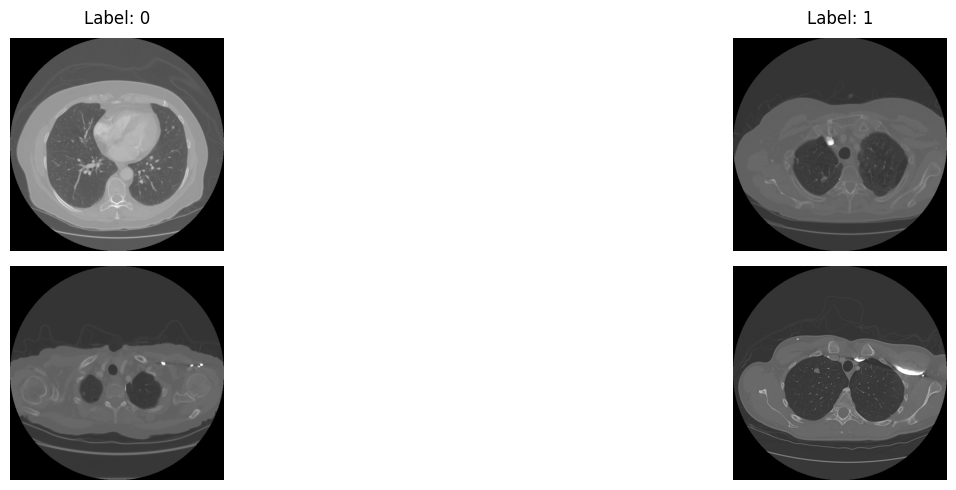

Random Nodule images


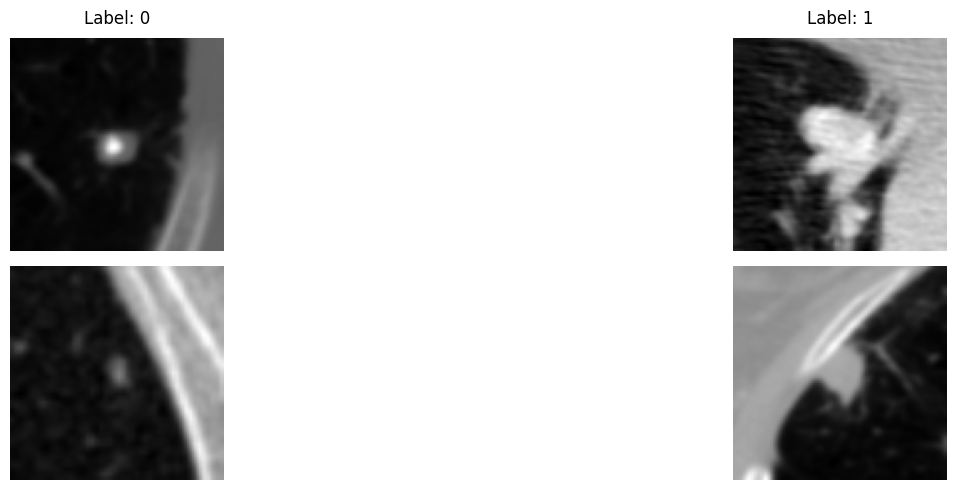

In [33]:
# Plot random images
print("Random Full_slice images")
plot_images(rows=2, images=images_full_slice, labels=labels)
print("Random Nodule images")
plot_images(rows=2, images=images_nodule, labels=labels)


 ### Now let's check for nan values or unexpected image shapes

In [34]:
# Usage example
#check_image_sizes(images_full_slice, images_nodule)


Good, none of the images have nan values or unexpected shapes. Now let's visualize them...

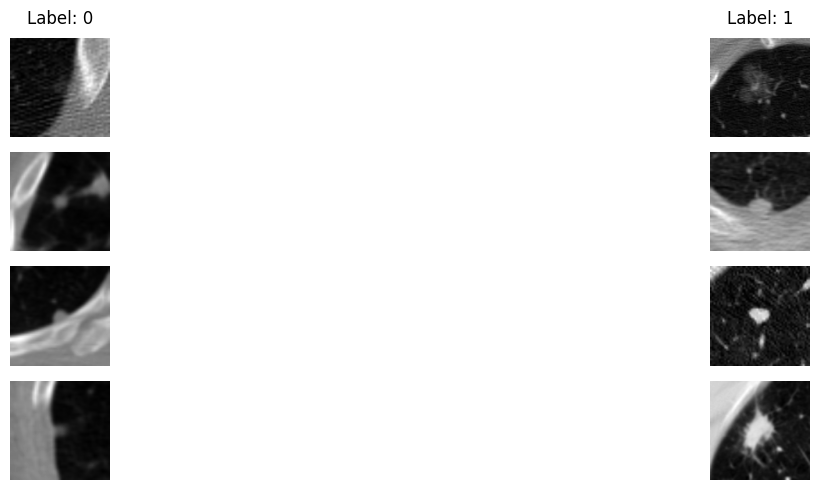

In [35]:
plot_images(4, images_nodule, labels)

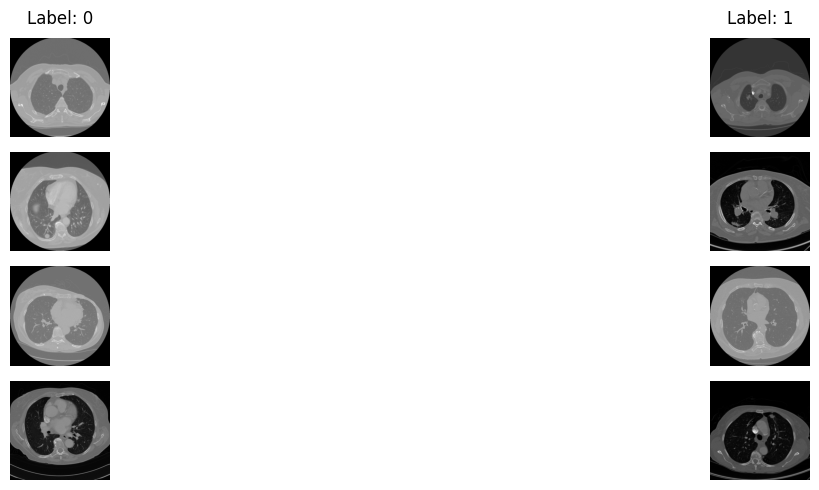

In [36]:
plot_images(4, images_full_slice, labels)

In [40]:
# Count occurrences of each label
unique_labels, counts = np.unique(labels, return_counts=True)
num_classes = np.unique(labels).size

print(f"Images are {images_full_slice.shape[1]}x{images_full_slice.shape[2]}")
print(f"There are {images_full_slice.shape[0]} samples")
print(f"Number of distinct labels are {num_classes}")

# Display the counts for each label
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} samples")

Images are 512x512
There are 2363 samples
Number of distinct labels are 2
Label 0: 1793 samples
Label 1: 570 samples


#### As a first step we split the data in train, validation and test sets

In [41]:
# Assuming `full_slice_images` and `nodule_images` are the respective input arrays
'''
X_f = prepared_data['full_slice'].to_numpy()  # Full slice images
X_n = prepared_data['nodule'].to_numpy()      # Nodule images
y = prepared_data['malignancy'].to_numpy()    # Labels
'''
X_f = images_full_slice
#X_n = images_nodule
y = labels


The **validation** set will help to evaluate the model during the training and
for hyperparameter tuning.

The **test** set will help to evaluate the model's performance on unseen data.

Split for dataset with 

In [42]:
# Training set (80%) and Validation + Test set (20%)
# We have also used stratification to keep the same class distribution after split
# Split for Full Slice
X_f_train, X_f_temp, y_f_train, y_f_temp = train_test_split(
    X_f, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

X_f_val, X_f_test, y_f_val, y_f_test = train_test_split(
    X_f_temp, y_f_temp, test_size=0.5, stratify=y_f_temp, random_state=RANDOM_SEED
)
'''
# Split for Nodule
X_n_train, X_n_temp, y_n_train, y_n_temp = train_test_split(
    X_n, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

X_n_val, X_n_test, y_n_val, y_n_test = train_test_split(
    X_n_temp, y_n_temp, test_size=0.5, stratify=y_n_temp, random_state=RANDOM_SEED
)



# Print dataset sizes for verification
print("\nFull Slice Data Splits:")
print(f"Training set size: {len(X_f_train)}")
print(f"Validation set size: {len(X_f_val)}")
print(f"Test set size: {len(X_f_test)}")

print("\nNodule Data Splits:")
print(f"Training set size: {len(X_n_train)}")
print(f"Validation set size: {len(X_n_val)}")
print(f"Test set size: {len(X_n_test)}")
'''

'\n# Split for Nodule\nX_n_train, X_n_temp, y_n_train, y_n_temp = train_test_split(\n    X_n, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED\n)\n\nX_n_val, X_n_test, y_n_val, y_n_test = train_test_split(\n    X_n_temp, y_n_temp, test_size=0.5, stratify=y_n_temp, random_state=RANDOM_SEED\n)\n\n\n\n# Print dataset sizes for verification\nprint("\nFull Slice Data Splits:")\nprint(f"Training set size: {len(X_f_train)}")\nprint(f"Validation set size: {len(X_f_val)}")\nprint(f"Test set size: {len(X_f_test)}")\n\nprint("\nNodule Data Splits:")\nprint(f"Training set size: {len(X_n_train)}")\nprint(f"Validation set size: {len(X_n_val)}")\nprint(f"Test set size: {len(X_n_test)}")\n'

In [43]:
'''
print("Sample from X_f_train:", X_f_train[0])
print("Type of X_f_train[0]:", type(X_f_train[0]))

print("Sample from X_n_train:", X_n_train[0])
print("Type of X_n_train[0]:", type(X_n_train[0]))
'''

'\nprint("Sample from X_f_train:", X_f_train[0])\nprint("Type of X_f_train[0]:", type(X_f_train[0]))\n\nprint("Sample from X_n_train:", X_n_train[0])\nprint("Type of X_n_train[0]:", type(X_n_train[0]))\n'


Label Distributions for Full Slice:


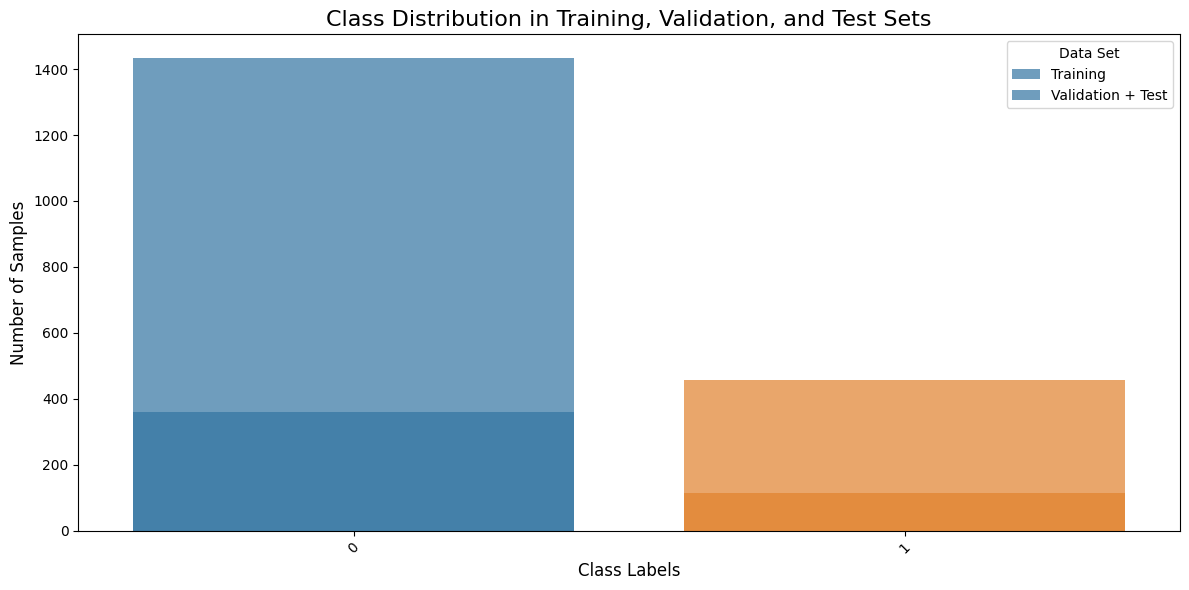

'\nprint("\nLabel Distributions for Nodule:")\nplot_labels_distribution(y_n_train, y_n_val, y_n_test)\n'

In [44]:
# Plot label distributions for both inputs
print("\nLabel Distributions for Full Slice:")
plot_labels_distribution(y_f_train, y_f_val, y_f_test)
'''
print("\nLabel Distributions for Nodule:")
plot_labels_distribution(y_n_train, y_n_val, y_n_test)
'''

To address the class imbalance in the dataset, we have used two approaches:

- **Compute class weights:** This helps to give more importance to the minority classes during training by adjusting the loss function, so the model pays more attention to underrepresented classes.

- **Increase the number of samples in the minority classes:** This is done using simple data augmentation techniques to artificially expand the dataset and provide the model with more diverse examples from underrepresented classes.

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Flatten the training labels for Full Slice
y_f_train_flat = y_f_train.ravel()

# Compute class weights for Full Slice
unique_labels_f = np.unique(y_f_train_flat)
class_weights_f = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels_f,
    y=y_f_train_flat
)
class_weight_dict_f = dict(enumerate(class_weights_f))
del y_f_train_flat

print("\nClass Weights for Full Slice:")
print(class_weight_dict_f)

'''
# Flatten the training labels for Nodule
y_n_train_flat = y_n_train.ravel()

# Compute class weights for Nodule
unique_labels_n = np.unique(y_n_train_flat)
class_weights_n = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels_n,
    y=y_n_train_flat
)
class_weight_dict_n = dict(enumerate(class_weights_n))
del y_n_train_flat

print("\nClass Weights for Nodule:")
print(class_weight_dict_n)
'''


Class Weights for Full Slice:
{0: 0.6589958158995816, 1: 2.0723684210526314}


'\n# Flatten the training labels for Nodule\ny_n_train_flat = y_n_train.ravel()\n\n# Compute class weights for Nodule\nunique_labels_n = np.unique(y_n_train_flat)\nclass_weights_n = compute_class_weight(\n    class_weight=\'balanced\',\n    classes=unique_labels_n,\n    y=y_n_train_flat\n)\nclass_weight_dict_n = dict(enumerate(class_weights_n))\ndel y_n_train_flat\n\nprint("\nClass Weights for Nodule:")\nprint(class_weight_dict_n)\n'

#### Prepare the dataset for augmentations

To prepare the dataset for image augmentations, we define several functions. Some augmentations, like CutMix and MixUp, require the data to be structured as a dictionary containing two key elements:

- A tensor of **images**
- A tensor of **labels** (one-hot encoded)

These functions will help ensure that the data is properly formatted for these specific augmentation techniques.

In [46]:
# Define image sizes for different input types
FULL_SLICE_IMAGE_SIZE = (512, 512)
NODULE_IMAGE_SIZE = (128, 128)  # Example size for nodules
BATCH_SIZE = 32

def to_dict(image, label, input_type="Full Slice"):
    """
    Transform image and label into the desired format.
    
    Parameters:
    - image: The input image tensor.
    - label: The corresponding label tensor.
    - input_type: Specifies whether the image is "Full Slice" or "Nodule".
    
    Returns:
    - A dictionary with transformed images and labels.
    """
    print("Shape image:", image.shape if hasattr(image, 'shape') else "No shape")
    print("Shape label:", label.shape if hasattr(label, 'shape') else "No shape")

    # Select image size based on input type
    if input_type == "Nodule":
        image_size = NODULE_IMAGE_SIZE
    else:  # Default to "Full Slice"
        image_size = FULL_SLICE_IMAGE_SIZE
        
    height, width = image_size
    
    # Add a channel dimension if the image is grayscale
    if tf.rank(image) == 2:
        image = tf.expand_dims(image, axis=-1)
        image = tf.image.grayscale_to_rgb(image)
        

    # Rescale the pixel values to the range [0, 255]
    image = (image - tf.reduce_min(image)) / (tf.reduce_max(image) - tf.reduce_min(image))# * 255.0

    # Set a known shape and resize the image
    image.set_shape((height, width, 3))  # Allow flexibility in dimensions
    #image = tf.image.resize(image, image_size)
    image = tf.cast(image, tf.float32)

    # One-hot encode the label
    if num_classes > 2:
        label = tfk.utils.to_categorical(label, num_classes)

    print("Transformed - Shape image:", image.shape)
    print("Transformed - Shape label:", label.shape)

    return {"images": image, "labels": label}

def prepare_dataset(dataset, split='train', input_type="Full Slice"):
    if split == 'train':
        return (
            dataset.shuffle(10 * BATCH_SIZE)
            .map(lambda img, lbl: to_dict(img, lbl, input_type), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
        )
    elif split == 'validation' or split == 'test':
        return (
            dataset.map(lambda img, lbl: to_dict(img, lbl, input_type), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
        )

def load_dataset(data, split='train', input_type="Full Slice"):
    return prepare_dataset(data, split, input_type)

def visualize_dataset(dataset, title):
    plt.figure(figsize=(6, 6)).suptitle(title, fontsize=18)
    for i, samples in enumerate(iter(dataset.take(9))):
        images = samples["images"]
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.show()


In [47]:
# Used to convert two numpy arrays (X: input features and y: target values) to a tensor dataset
def to_tensor_dataset(X, y):
  X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)
  y_tensor = tf.convert_to_tensor(y, dtype=tf.uint8)

  return tf.data.Dataset.from_tensor_slices((X_tensor, y_tensor))

In [48]:
# Check for irregular shapes in X_f_train
print("\nChecking shapes in X_f_train:")
for i, sample in enumerate(X_f_train):
    print(f"Sample {i} shape: {sample.shape}")
    if i > 10:  # Limit to first 10 samples
        break
'''
# Check for irregular shapes in X_n_train
print("\nChecking shapes in X_n_train:")
for i, sample in enumerate(X_n_train):
    print(f"Sample {i} shape: {sample.shape}")
    if i > 10:  # Limit to first 10 samples
        break
'''


Checking shapes in X_f_train:
Sample 0 shape: (512, 512)
Sample 1 shape: (512, 512)
Sample 2 shape: (512, 512)
Sample 3 shape: (512, 512)
Sample 4 shape: (512, 512)
Sample 5 shape: (512, 512)
Sample 6 shape: (512, 512)
Sample 7 shape: (512, 512)
Sample 8 shape: (512, 512)
Sample 9 shape: (512, 512)
Sample 10 shape: (512, 512)
Sample 11 shape: (512, 512)


'\n# Check for irregular shapes in X_n_train\nprint("\nChecking shapes in X_n_train:")\nfor i, sample in enumerate(X_n_train):\n    print(f"Sample {i} shape: {sample.shape}")\n    if i > 10:  # Limit to first 10 samples\n        break\n'

problem with shape of nodule images because it's not fixed and all the images are grey images

In [49]:
print("X_f_train shape:", np.shape(X_f_train), "dtype:", type(X_f_train))
print("y_f_train shape:", np.shape(y_f_train), "dtype:", type(y_f_train))
'''
print("X_n_train shape:", np.shape(X_n_train), "dtype:", type(X_n_train))
print("y_n_train shape:", np.shape(y_n_train), "dtype:", type(y_n_train))
'''

X_f_train shape: (1890, 512, 512) dtype: <class 'numpy.ndarray'>
y_f_train shape: (1890,) dtype: <class 'numpy.ndarray'>


'\nprint("X_n_train shape:", np.shape(X_n_train), "dtype:", type(X_n_train))\nprint("y_n_train shape:", np.shape(y_n_train), "dtype:", type(y_n_train))\n'

In [50]:

# Convert datasets separately for full_slice and nodule
train_dataset_f = to_tensor_dataset(X_f_train, y_f_train)
val_dataset_f = to_tensor_dataset(X_f_val, y_f_val)
test_dataset_f = to_tensor_dataset(X_f_test, y_f_test)

'''
train_dataset_n = to_tensor_dataset(X_n_train, y_n_train)
val_dataset_n = to_tensor_dataset(X_n_val, y_n_val)
test_dataset_n = to_tensor_dataset(X_n_test, y_n_test)

'''

'\ntrain_dataset_n = to_tensor_dataset(X_n_train, y_n_train)\nval_dataset_n = to_tensor_dataset(X_n_val, y_n_val)\ntest_dataset_n = to_tensor_dataset(X_n_test, y_n_test)\n\n'

In [51]:
for sample in train_dataset_f.take(1):
    print("Sample:", sample)
    print("Image shape:", sample[0].shape if hasattr(sample[0], 'shape') else "No shape")
    print("Label shape:", sample[1].shape if hasattr(sample[1], 'shape') else "No shape")

for sample in train_dataset_f.take(5):
    print("Image shape:", sample[0].shape)
    
for sample in train_dataset_f.take(5):
    print("Valid image:", sample[0] is not None)


Sample: (<tf.Tensor: shape=(512, 512), dtype=float32, numpy=
array([[ -946.,  -977., -1010., ...,  -950.,  -979., -1011.],
       [ -991.,  -960.,  -967., ...,  -942., -1007., -1023.],
       [-1015.,  -997.,  -979., ...,  -966., -1024., -1024.],
       ...,
       [-1020., -1002., -1001., ...,  -977., -1012., -1007.],
       [-1005.,  -985.,  -984., ...,  -958.,  -990., -1019.],
       [ -965.,  -972.,  -972., ..., -1005.,  -994.,  -995.]],
      dtype=float32)>, <tf.Tensor: shape=(), dtype=uint8, numpy=0>)
Image shape: (512, 512)
Label shape: ()
Image shape: (512, 512)
Image shape: (512, 512)
Image shape: (512, 512)
Image shape: (512, 512)
Image shape: (512, 512)
Valid image: True
Valid image: True
Valid image: True
Valid image: True
Valid image: True


In [52]:
# Prepare TensorFlow datasets for full_slice
train_dataset_f = load_dataset(train_dataset_f, input_type="Full Slice")
val_dataset_f = load_dataset(val_dataset_f, 'validation', input_type="Full Slice")
test_dataset_f = load_dataset(test_dataset_f, 'test', input_type="Full Slice")
'''
# Prepare TensorFlow datasets for nodule
train_dataset_n = load_dataset(train_dataset_n, input_type="Nodule")
val_dataset_n = load_dataset(val_dataset_n, 'validation', input_type="Nodule")
test_dataset_n = load_dataset(test_dataset_n, 'test', input_type="Nodule")
'''

Shape image: (512, 512)
Shape label: ()
Transformed - Shape image: (512, 512, 3)
Transformed - Shape label: ()
Shape image: (512, 512)
Shape label: ()
Transformed - Shape image: (512, 512, 3)
Transformed - Shape label: ()
Shape image: (512, 512)
Shape label: ()
Transformed - Shape image: (512, 512, 3)
Transformed - Shape label: ()


'\n# Prepare TensorFlow datasets for nodule\ntrain_dataset_n = load_dataset(train_dataset_n, input_type="Nodule")\nval_dataset_n = load_dataset(val_dataset_n, \'validation\', input_type="Nodule")\ntest_dataset_n = load_dataset(test_dataset_n, \'test\', input_type="Nodule")\n'

In [53]:
def revert_to_numpy(dataset):
  # Lists to accumulate images and labels
  all_images = []
  all_labels = []

  # Iterate over the dataset
  for batch in dataset:
      images = batch['images']  # Access the images
      labels = batch['labels']  # Access the labels

      # Append the data to the lists
      all_images.append(images.numpy())  # Convert tensor to numpy array and append
      all_labels.append(labels.numpy())  # Convert tensor to numpy array and append

  # Convert the lists to numpy arrays
  X_train = np.concatenate(all_images, axis=0)  # Concatenate all images
  y_train = np.concatenate(all_labels, axis=0)  # Concatenate all labels

  return X_train, y_train

In [54]:

# Revert `full_slice` datasets to NumPy
X_train_f, y_train_f = revert_to_numpy(train_dataset_f)
X_val_f, y_val_f = revert_to_numpy(val_dataset_f)
X_test_f, y_test_f = revert_to_numpy(test_dataset_f)
'''
# Revert `nodule` datasets to NumPy
X_train_n, y_train_n = revert_to_numpy(train_dataset_n)
X_val_n, y_val_n = revert_to_numpy(val_dataset_n)
X_test_n, y_test_n = revert_to_numpy(test_dataset_n)

# Verify the shapes of the converted data
print(f"Full Slice - Training Data: {X_train_f.shape}, Labels: {y_train_f.shape}")
print(f"Full Slice - Validation Data: {X_val_f.shape}, Labels: {y_val_f.shape}")
print(f"Full Slice - Test Data: {X_test_f.shape}, Labels: {y_test_f.shape}")
print(f"Nodule - Training Data: {X_train_n.shape}, Labels: {y_train_n.shape}")
print(f"Nodule - Validation Data: {X_val_n.shape}, Labels: {y_val_n.shape}")
print(f"Nodule - Test Data: {X_test_n.shape}, Labels: {y_test_n.shape}")
'''

'\n# Revert `nodule` datasets to NumPy\nX_train_n, y_train_n = revert_to_numpy(train_dataset_n)\nX_val_n, y_val_n = revert_to_numpy(val_dataset_n)\nX_test_n, y_test_n = revert_to_numpy(test_dataset_n)\n\n# Verify the shapes of the converted data\nprint(f"Full Slice - Training Data: {X_train_f.shape}, Labels: {y_train_f.shape}")\nprint(f"Full Slice - Validation Data: {X_val_f.shape}, Labels: {y_val_f.shape}")\nprint(f"Full Slice - Test Data: {X_test_f.shape}, Labels: {y_test_f.shape}")\nprint(f"Nodule - Training Data: {X_train_n.shape}, Labels: {y_train_n.shape}")\nprint(f"Nodule - Validation Data: {X_val_n.shape}, Labels: {y_val_n.shape}")\nprint(f"Nodule - Test Data: {X_test_n.shape}, Labels: {y_test_n.shape}")\n'

In [55]:
target_size = (256, 256)
X_train_f = tf.image.resize(X_train_f, target_size)
X_val_f = tf.image.resize(X_val_f, target_size)
X_test_f = tf.image.resize(X_test_f, target_size)

**LOADING MODELS**

In [56]:
from keras.models import load_model
import numpy as np

In [185]:
# Select a random index from X_test_f
random_index = np.random.randint(0, len(X_test_f))

# Select the corresponding image
sample_image = X_test_f[random_index]


In [186]:
print(f"Shape of selected image: {sample_image.shape}")

Shape of selected image: (256, 256, 3)


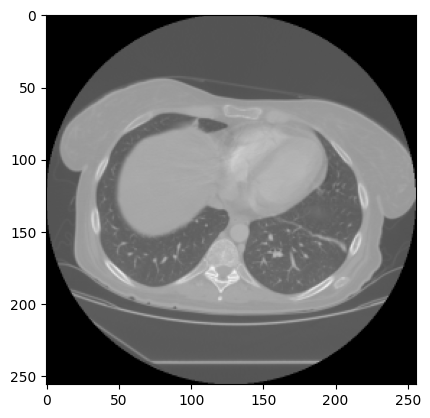

In [187]:
# Display the image
plt.imshow(sample_image)


# **VISUALIZING GRAD CAM**

**CNN model**

In [188]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import scipy

def compute_gradcam(model, img, base_model, layer_name):

# Expand image dimensions to fit the model input shape
    
    # ✅ Ensure input is properly batched
    if len(img.shape) == 3:  # Expand only if it's not already batched
        img = np.expand_dims(img, axis=0)  # Shape becomes (1, 256, 256, 3)

    # Convert image to tensor
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    img = tf.ensure_shape(img, (1, 256, 256, 3))

    # Predict to get the winning class
    predictions = model.predict(img, verbose=0)
    
    #label_index = np.argmax(predictions) # multiclass
    label_index = int(predictions > 0.5) # binary

    # Get the 1536 input weights to the softmax of the winning class
    dense_layer = model.get_layer("dense_4")  # This connects to the CNN features
    class_weights = dense_layer.get_weights()[0] # weights from the layer after convolution

    class_weights_winner = class_weights[:, label_index]

    # Define the final convolutional layer of the base model
    final_conv_layer = tfk.Model(
        model.get_layer(base_model).input,
        model.get_layer(base_model).get_layer(layer_name).output
    )

    # Compute the convolutional outputs and squeeze the dimensions
    conv_outputs = final_conv_layer(img)
    conv_outputs = conv_outputs.numpy().astype(np.float32)
    conv_outputs = np.squeeze(conv_outputs).astype(np.float32)
    
    print((conv_outputs.shape , class_weights_winner.shape))
    print((conv_outputs.shape , class_weights_winner.shape))
    
    print(f"Conv Output Shape: {conv_outputs.shape}")  # (8,8,1024)
    print(f"Class Weights Shape: {class_weights.shape}")  # (1024,128)

    scale_x = img.shape[1] / conv_outputs.shape[0]  # Larghezza
    scale_y = img.shape[2] / conv_outputs.shape[1]  # Altezza
    # Upsample the convolutional outputs and compute the final output using the class weights
    mat_for_mult = scipy.ndimage.zoom(conv_outputs, (scale_x , scale_y, 1), order=1)
    print(f"Shapes mat_for_mult {mat_for_mult.shape} , class_weights_winner {class_weights_winner.shape} ")
    # Ensure mat_for_mult has the correct shape before reshaping
    num_channels = conv_outputs.shape[-1]  # Should be 1024
    height, width = mat_for_mult.shape[:2]  # 256, 256

    # Make sure class_weights_winner has the same number of channels
    assert class_weights_winner.shape[0] == num_channels, f"Shape mismatch: {class_weights_winner.shape[0]} vs {num_channels}"

    # Reshape to match the expected format
    final_output = np.dot(mat_for_mult.reshape((height * width, num_channels)), class_weights_winner).reshape(height, width)

    print("here2")
    return final_output, label_index, predictions


# 🔹 Function to Overlay Grad-CAM on Image
def overlay_gradcam(img, heatmap, alpha=0.4):
    """
    Overlays the Grad-CAM heatmap onto the original image.

    Parameters:
        - img: Original image (numpy array).
        - heatmap: Grad-CAM heatmap.
        - alpha: Opacity of the heatmap overlay.

    Returns:
        - superimposed_img: Image with Grad-CAM overlay.
    """
    # ✅ Resize heatmap to match image size
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # ✅ Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # ✅ Overlay heatmap onto image
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    return superimposed_img

# 🔹 Function to Display Grad-CAM
def show_gradcam(model, base_model, img, layer_name, class_index=None):
    """
    Generates and displays Grad-CAM visualization.

    Parameters:
        - model: Full classification model.
        - base_model: The DenseNet121 base model inside the full model.
        - img: Original image (numpy array).
        - layer_name: Name of the layer to visualize.
        - class_index: Index of the class to visualize (default: predicted class).
    """
    # ✅ Preprocess the image
    img_array = np.expand_dims(img, axis=0)  # Add batch dimension


    # ✅ Compute Grad-CAM heatmap
    #heatmap = compute_gradcam(model, img_array, base_model, layer_name, class_index)
    final_output, label_index, predictions = compute_gradcam(model, img_array, base_model, layer_name)
    final_output.shape , label_index, predictions.shape # label_index.shape if multiclass
    # Normalize the heatmap to the range [0, 1]
    heatmap = final_output
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    # ✅ Plot results
    # Plot the image
    plt.imshow(img, cmap='gray')  # Display the grayscale image
    plt.imshow(heatmap, cmap='jet', alpha=0.2)  # Overlay the heatmap with transparency

    # Add color bar for the heatmap
    plt.colorbar(label="Heatmap Intensity")

    # Remove axes for better visualization
    plt.axis('off')

    # Show the plot
    plt.show()





In [189]:
model = load_model("/kaggle/input/densenet/keras/default/1/DenseNet121_binary_full_slice_withFourierAug_weights.keras")
model_name = "DenseNet121"


#last_conv_layer_name = "conv5_block16_concat"  # Update this to your last CNN layer


In [190]:
# Get the base model from your full model
base_model = model.get_layer("densenet121")  # Usually the second layer is EfficientNet
  # Adjust name if needed


In [191]:
# Get the base DenseNet121 model
base_model = model.get_layer("densenet121")  # Ensure this is the correct layer name


# Print the last few layers to check their names
for layer in base_model.layers[-10:]:  # Print last 10 layers
    print(layer.name, type(layer))


conv5_block15_concat <class 'keras.src.layers.merging.concatenate.Concatenate'>
conv5_block16_0_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
conv5_block16_0_relu <class 'keras.src.layers.activations.activation.Activation'>
conv5_block16_1_conv <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
conv5_block16_1_bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
conv5_block16_1_relu <class 'keras.src.layers.activations.activation.Activation'>
conv5_block16_2_conv <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
conv5_block16_concat <class 'keras.src.layers.merging.concatenate.Concatenate'>
bn <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
relu <class 'keras.src.layers.activations.activation.Activation'>


In [192]:
# Print the first few layers to check their names
for layer in model.layers[:10]:  # Print first 10 layers
    print(layer.name, type(layer))

input_layer_5 <class 'keras.src.layers.core.input_layer.InputLayer'>
densenet121 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d_2 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
group_normalization_4 <class 'keras.src.layers.normalization.group_normalization.GroupNormalization'>
dropout_4 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_4 <class 'keras.src.layers.core.dense.Dense'>
group_normalization_5 <class 'keras.src.layers.normalization.group_normalization.GroupNormalization'>
dropout_5 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_5 <class 'keras.src.layers.core.dense.Dense'>


In [193]:
last_conv_layer = "relu"

In [194]:
if last_conv_layer not in [layer.name for layer in base_model.layers]:
    raise ValueError(f"Layer '{last_conv_layer_name}' not found in base model. Check layer names!")


((8, 8, 1024), (1024,))
((8, 8, 1024), (1024,))
Conv Output Shape: (8, 8, 1024)
Class Weights Shape: (1024, 128)
Shapes mat_for_mult (256, 256, 1024) , class_weights_winner (1024,) 
here2


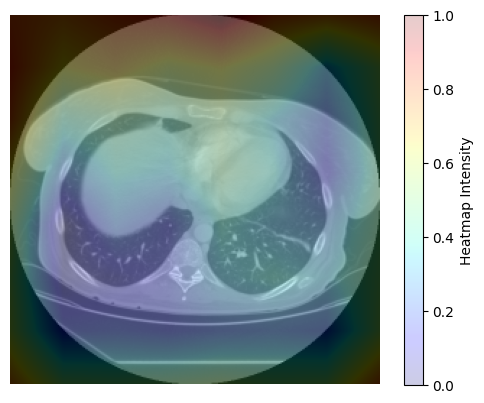

In [195]:
# Generate Grad-CAM visualization
base_model_name = "densenet121"
show_gradcam(model, base_model_name, sample_image, last_conv_layer)
#last_conv_layer_name

**AUTOENCODER**

In [196]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import scipy

def compute_autoencoder_gradcam(model, img, base_model, layer_name):
    """
    Computes Grad-CAM for an autoencoder by extracting activations from the last conv layer of the encoder.
    
    Parameters:
        - autoencoder: Trained autoencoder model.
        - img: Input image (numpy array of shape (256, 256, 3)).
        - encoder_name: Name of the encoder inside the autoencoder.
        - layer_name: Name of the convolutional layer to visualize.

    Returns:
        - heatmap: Grad-CAM heatmap of the encoder's most important activations.
    """

    # ✅ Ensure input is properly batched
    if len(img.shape) == 3:  # Expand only if it's not already batched
        img = np.expand_dims(img, axis=0)  # Shape becomes (1, 256, 256, 3)

    # Convert image to tensor
    img = tf.convert_to_tensor(img, dtype=tf.float32)
    img = tf.ensure_shape(img, (1, 256, 256, 3))

    # Predict to get the winning class 
    #predictions = model.predict(img, verbose=0)
    # ✅ First, pass the image through the encoder to extract features
    latent_features = base_model.predict(img, verbose=0)  

    # ✅ Then pass the latent features to the classifier
    predictions = model.predict(latent_features, verbose=0)

    #label_index = np.argmax(predictions) # multiclass
    label_index = int(predictions > 0.5) # binary

    # Get the 1536 input weights to the softmax of the winning class
    dense_layer = model.get_layer("dense_2")  # This connects to the encoder features



    # Define the final convolutional layer of the base model
    final_conv_layer = tfk.Model(
        inputs=base_model.input, 
        outputs=base_model.get_layer(layer_name).output  # Extract feature maps
    )

    # Compute the convolutional outputs and squeeze the dimensions
    conv_outputs = final_conv_layer(img)
    conv_outputs = conv_outputs.numpy().astype(np.float32)
    conv_outputs = np.squeeze(conv_outputs).astype(np.float32)
      

    class_weights = dense_layer.get_weights()[0] # weights from the layer after convolution
    print(f"Class_weights: {class_weights.shape}")# (64, 256)
    class_weights_winner = class_weights[:, label_index]
    # Resize class_weights_winner to match convolutional channels (256)
    class_weights_winner = np.resize(class_weights_winner, (conv_outputs.shape[-1],))

    print((conv_outputs.shape , class_weights_winner.shape))
    print((conv_outputs.shape , class_weights_winner.shape))
    
    print(f"Conv Output Shape: {conv_outputs.shape}") 
    print(f"Class Weights Shape: {class_weights.shape}")

    scale_x = img.shape[1] / conv_outputs.shape[0]  # Larghezza
    scale_y = img.shape[2] / conv_outputs.shape[1]  # Altezza
    # Upsample the convolutional outputs and compute the final output using the class weights
    mat_for_mult = scipy.ndimage.zoom(conv_outputs, (scale_x , scale_y, 1), order=1)
    print(f"Shapes mat_for_mult {mat_for_mult.shape} , class_weights_winner {class_weights_winner.shape} ")
    # Ensure mat_for_mult has the correct shape before reshaping
    num_channels = conv_outputs.shape[-1]  
    height, width = mat_for_mult.shape[:2] 

    # Make sure class_weights_winner has the same number of channels
    assert class_weights_winner.shape[0] == num_channels, f"Shape mismatch: {class_weights_winner.shape[0]} vs {num_channels}"

    # Reshape to match the expected format
    final_output = np.dot(mat_for_mult.reshape((height * width, num_channels)), class_weights_winner).reshape(height, width)

    print("here2")
    return final_output, label_index, predictions


# 🔹 Function to Display Grad-CAM
def show_autoencoder_gradcam(model, base_model, img, layer_name, class_index=None):
    """
    Generates and displays Grad-CAM visualization.

    Parameters:
        - model: Full classification model.
        - base_model: The DenseNet121 base model inside the full model.
        - img: Original image (numpy array).
        - layer_name: Name of the layer to visualize.
        - class_index: Index of the class to visualize (default: predicted class).
    """
    # ✅ Preprocess the image
    img_array = np.expand_dims(img, axis=0)  # Add batch dimension


    # ✅ Compute Grad-CAM heatmap
    #heatmap = compute_gradcam(model, img_array, base_model, layer_name, class_index)
    final_output, label_index, predictions = compute_autoencoder_gradcam(model, img_array, base_model, layer_name)
    final_output.shape , label_index, predictions.shape # label_index.shape if multiclass
    # Normalize the heatmap to the range [0, 1]
    heatmap = final_output
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap))

    # ✅ Plot results
    # Plot the image
    plt.imshow(img, cmap='gray')  # Display the grayscale image
    plt.imshow(heatmap, cmap='jet', alpha=0.2)  # Overlay the heatmap with transparency

    # Add color bar for the heatmap
    plt.colorbar(label="Heatmap Intensity")

    # Remove axes for better visualization
    plt.axis('off')

    # Show the plot
    plt.show()





In [197]:
encoder = load_model('/kaggle/input/encoder/keras/default/1/encoder_weights.keras')
base_model = encoder
model = load_model('/kaggle/input/classifier/keras/default/1/classifier_weights.keras')


In [198]:

# Print the first few layers to check their names
for layer in model.layers[:10]:  # Print first 10 layers
    print(layer.name, type(layer))

dense_2 <class 'keras.src.layers.core.dense.Dense'>
batch_normalization_8 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_3 <class 'keras.src.layers.core.dense.Dense'>
batch_normalization_9 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_4 <class 'keras.src.layers.core.dense.Dense'>
batch_normalization_10 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
dense_5 <class 'keras.src.layers.core.dense.Dense'>


In [199]:
# Print the last few layers to check their names
for layer in encoder.layers[-10:]:  # Print last 10 layers
    print(layer.name, type(layer))

leaky_re_lu_2 <class 'keras.src.layers.activations.leaky_relu.LeakyReLU'>
batch_normalization_2 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
max_pooling2d_2 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
conv2d_3 <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
leaky_re_lu_3 <class 'keras.src.layers.activations.leaky_relu.LeakyReLU'>
batch_normalization_3 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
max_pooling2d_3 <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>
flatten <class 'keras.src.layers.reshaping.flatten.Flatten'>
dense <class 'keras.src.layers.core.dense.Dense'>
gaussian_noise <class 'keras.src.layers.regularization.gaussian_noise.GaussianNoise'>


In [200]:
last_conv_layer = "max_pooling2d_3"

Class_weights: (64, 256)
((16, 16, 256), (256,))
((16, 16, 256), (256,))
Conv Output Shape: (16, 16, 256)
Class Weights Shape: (64, 256)
Shapes mat_for_mult (256, 256, 256) , class_weights_winner (256,) 
here2


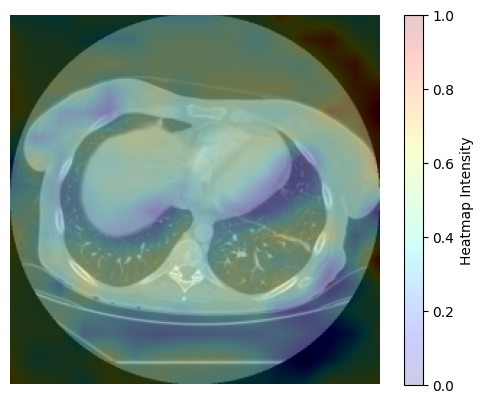

In [201]:
# Generate Grad-CAM visualization
show_autoencoder_gradcam(model, base_model, sample_image, last_conv_layer)


**LOCALIZATION + CLASSIFIER**